In [2]:
# Import necessary libraries
from datetime import datetime, timedelta
import h5py
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
import pandas as pd
import pickle
import re
from scipy.signal import spectrogram
from tqdm import tqdm

## Data Upload

In [3]:
dataframes = {}
file_paths = {}
start_times = {}


### Load Temperature Data

In [4]:
# Ask for temperature_filepath
while True:
    temperature_filepath = input("Enter the absolute path to temperature (.lvm) file. ").strip('"')
    if os.path.isfile(temperature_filepath):
        # Number of rows to skip
        skip = 22

        dataframes["temperature"] = pd.read_csv(temperature_filepath, skiprows=skip, sep='\t')
        file_paths["temperature"] = temperature_filepath
        
        # Extract start time from file header
        with open(temperature_filepath, 'r') as f:
            time_str = None
            for line in f:
                line = line.strip()
                if line.startswith('Time\t'):
                    time_str = line.split('\t')[1]
                    break
        
        # Parse time into datetime object (will default to 1900-01-01)
        if time_str:
            # Handle the high precision time by truncating to microseconds
            time_parts = time_str.split('.')
            if len(time_parts) > 1:
                # Keep only first 6 digits after decimal for microseconds
                microseconds = time_parts[1][:6].ljust(6, '0')
                time_str = f"{time_parts[0]}.{microseconds}"
            
            start_times["temperature"] = pd.to_datetime(time_str, format='%H:%M:%S.%f')
        else:
            # Fallback if time not found in expected format
            start_times["temperature"] = None
            print("Warning: Could not extract start time from file header")
        
        print(f"✅ Loaded and stored temperature file (skiprows={skip})")
        print(f"Start time: {start_times['temperature']}")
        display(dataframes["temperature"])
        break
    elif temperature_filepath.strip().lower() == "skip":
        print(f"✅ Skipping loading temperature file")
        break
    print("Invalid file. Try again.")

temperature_data_synchronized = False

✅ Loaded and stored temperature file (skiprows=22)
Start time: 1900-01-01 15:03:04.733707


,X_Value,Thermo-couple_1,Thermo-couple_2,Thermo-couple_3,Thermo-couple_4,Vapour Temp,Liquid Temp,Comment
0,0.000000,92.415539,92.868708,92.688388,93.134758,91.597127,96.329301,NaN
1,0.000333,92.415539,92.868708,92.688388,93.134758,91.597127,96.329301,NaN
2,0.000667,92.415539,92.868708,92.688388,93.134758,91.597127,96.329301,NaN
3,0.001000,92.415539,92.868708,92.688388,93.134758,91.597127,96.329301,NaN
4,0.001333,92.415539,92.868708,92.688388,93.134758,91.597127,96.329301,NaN
...,...,...,...,...,...,...,...,...
968995,322.990258,108.511460,108.324231,107.398579,107.401402,89.733577,93.334815,NaN
968996,322.990592,108.511460,108.324231,107.398579,107.401402,89.733577,93.334815,NaN
968997,322.990925,108.511460,108.324231,107.398579,107.401402,89.733577,93.334815,NaN
968998,322.991258,108.511460,108.324231,107.398579,107.401402,89.733577,93.334815,NaN


### Load Pressure Data

In [5]:
# Ask for pressure_filepath
while True:
    pressure_filepath = input("Enter the absolute path to pressure (.lvm) file. ").strip('"')
    if os.path.isfile(pressure_filepath):
        # Number of rows to skip
        skip = 22

        dataframes["pressure"] = pd.read_csv(pressure_filepath, skiprows=skip, sep='\t')
        file_paths["pressure"] = pressure_filepath

        # Extract start time from file header
        with open(pressure_filepath, 'r') as f:
            time_str = None
            for line in f:
                line = line.strip()
                if line.startswith('Time\t'):
                    time_str = line.split('\t')[1]
                    break
        
        # Parse time into datetime object (will default to 1900-01-01)
        if time_str:
            # Handle the high precision time by truncating to microseconds
            time_parts = time_str.split('.')
            if len(time_parts) > 1:
                # Keep only first 6 digits after decimal for microseconds
                microseconds = time_parts[1][:6].ljust(6, '0')
                time_str = f"{time_parts[0]}.{microseconds}"
            
            start_times["pressure"] = pd.to_datetime(time_str, format='%H:%M:%S.%f')
        else:
            # Fallback if time not found in expected format
            start_times["pressure"] = None
            print("Warning: Could not extract start time from file header")
        
        print(f"✅ Loaded and stored pressure file (skiprows={skip})")
        print(f"Start time: {start_times['pressure']}")
        display(dataframes["pressure"])
        break
    elif pressure_filepath.strip().lower() == "skip":
        print(f"✅ Skipping loading pressure file")
        break
    print("Invalid file. Try again.")

✅ Loaded and stored pressure file (skiprows=22)
Start time: 1900-01-01 15:03:04.029891


,X_Value,Voltage,Comment
0,0.00000,96.987161,NaN
1,0.00004,97.116763,NaN
2,0.00008,97.162154,NaN
3,0.00012,97.087882,NaN
4,0.00016,96.995080,NaN
...,...,...,...
8074995,322.99980,96.985195,NaN
8074996,322.99984,96.966717,NaN
8074997,322.99988,97.002948,NaN
8074998,322.99992,97.049167,NaN


### Rename Columns

In [6]:
# Rename columns after loading
if 'temperature' in dataframes:
    df_temp = dataframes['temperature']
    old_col = df_temp.columns[0]
    df_temp.rename(columns={old_col: 'Time (sec)'}, inplace=True)
    dataframes['temperature'] = df_temp
    display(dataframes['temperature'])
    print(f"✅ Renamed first column of temperature to 'Time'")

if 'pressure' in dataframes:
    df_press = dataframes['pressure']
    col_map = {
        df_press.columns[0]: 'Time (sec)',
        df_press.columns[1]: 'Pressure (kPa)',
    }
    df_press.rename(columns=col_map, inplace=True)
    dataframes['pressure'] = df_press
    display(dataframes['pressure'])
    print(f"✅ Renamed first two columns of pressure to 'Time' and 'Pressure'")

if 'combined' in dataframes:
    df_comb = dataframes['combined']
    col_map = {
        df_comb.columns[0]: 'Time (sec)',
        df_comb.columns[1]: 'Heat Flux (W/cm^2)',
        df_comb.columns[2]: 'Slope',
        df_comb.columns[3]: 'T_surface (degC)'
    }
    df_comb.rename(columns=col_map, inplace=True)
    dataframes['combined'] = df_comb
    print(f"✅ Renamed first four columns of combined")

,Time (sec),Thermo-couple_1,Thermo-couple_2,Thermo-couple_3,Thermo-couple_4,Vapour Temp,Liquid Temp,Comment
0,0.000000,92.415539,92.868708,92.688388,93.134758,91.597127,96.329301,NaN
1,0.000333,92.415539,92.868708,92.688388,93.134758,91.597127,96.329301,NaN
2,0.000667,92.415539,92.868708,92.688388,93.134758,91.597127,96.329301,NaN
3,0.001000,92.415539,92.868708,92.688388,93.134758,91.597127,96.329301,NaN
4,0.001333,92.415539,92.868708,92.688388,93.134758,91.597127,96.329301,NaN
...,...,...,...,...,...,...,...,...
968995,322.990258,108.511460,108.324231,107.398579,107.401402,89.733577,93.334815,NaN
968996,322.990592,108.511460,108.324231,107.398579,107.401402,89.733577,93.334815,NaN
968997,322.990925,108.511460,108.324231,107.398579,107.401402,89.733577,93.334815,NaN
968998,322.991258,108.511460,108.324231,107.398579,107.401402,89.733577,93.334815,NaN


✅ Renamed first column of temperature to 'Time'


,Time (sec),Pressure (kPa),Comment
0,0.00000,96.987161,NaN
1,0.00004,97.116763,NaN
2,0.00008,97.162154,NaN
3,0.00012,97.087882,NaN
4,0.00016,96.995080,NaN
...,...,...,...
8074995,322.99980,96.985195,NaN
8074996,322.99984,96.966717,NaN
8074997,322.99988,97.002948,NaN
8074998,322.99992,97.049167,NaN


✅ Renamed first two columns of pressure to 'Time' and 'Pressure'


### Load AE Hits Data

In [7]:
Mistras_filepath = ""
while True:
    Mistras_filepath = input("Please enter the absolute filepath of your Mistras .txt file (Enter 'None' to skip Mistras import): ")
    Mistras_filepath = Mistras_filepath.strip('"')

    if os.path.isfile(Mistras_filepath):
        print("\nMistras Data Filepath: ", f"\"{Mistras_filepath}\"")
        break
    print("\nThe specified file does not exist. Please check the path and try again.")
    
def get_mistras_metadata(filepath, df):
    metadata = {}
    
    # This regex pattern matches a time format and optionally captures microseconds if present
    time_pattern = re.compile(r'\b(\d{2}:\d{2}:\d{2})(?:\.(\d+))?\b')
    
    with open(filepath, 'r') as file:
        for line in file:
            match = re.search(time_pattern, line)
            if match:
                time_str = match.group(1)  # Time in HH:MM:SS
                microseconds_str = match.group(2) if match.group(2) else '000000'  # Microseconds part if present, else '0'
                break
        else:
            # Handle case where no time is found
            return None

    # Append microseconds to the time string and parse
    full_time_str = f"{time_str}.{microseconds_str}"
    time_obj = datetime.strptime(full_time_str, "%H:%M:%S.%f")

    metadata['start_time'] = time_obj
    metadata['duration'] = df['SSSSSSSS.mmmuuun'].iloc[-1]
    return metadata

def import_mistras_file_to_df(filepath):
    # Read the data using read_csv, assuming tab-separated values (TSV); adjust delimiter if needed
    df = pd.read_csv(filepath, sep='\s+', header=4)
    # There is a bad import on the 'SIG STRNGTH col because it has a space in the name and the file is whitespace-delimted
    column_names_AE_Node = [
        'ID', 'SSSSSSSS.mmmuuun', 'CH', 'RISE', 'COUN', 'ENER', 
        'DURATION', 'AMP', 'A-FRQ', 'RMS', 'ASL', 'PCNTS', 'THR', 'R-FRQ', 
        'I-FRQ', 'SIG STRNGTH', 'ABS-ENERGY'
    ]
    column_names_EasyAE = [
        'ID', 'SSSSSSSS.mmmuuun', 'PARA1', 'CH', 
        'RISE', 'COUN', 'ENER', 
        'DURATION', 'A-FRQ', 'RMS', 'PCNTS', 'THR', 'R-FRQ', 
        'I-FRQ', 'SIG STRNGTH', 'ABS-ENERGY', 'FRQ-C', 'P-FRQ', 'AMP', 'ASL'
    ]
    column_names = column_names_EasyAE
    # Keep all columns except the last one
    df = df.iloc[:, :-1]
    df.columns = column_names
    # Remove rows where any value is not a float
    # Attempt to convert all values to float
    df = df.apply(pd.to_numeric, errors='coerce')

    # Drop rows with any NaNs (i.e., conversion failures)
    df = df.dropna(how='any')

    return df

def process_mistras_df(df, metadata):
    # Drop 'ID' col
    df = df.drop('ID', axis=1)
    # Rename time col
    df.rename(columns={'SSSSSSSS.mmmuuun': 'TIME'}, inplace=True)
    
    # Add 'Absolute time' column to the data
    mistras_start_time_obj = metadata['start_time']
    seconds = df['TIME']
    time_deltas = pd.to_timedelta(seconds, unit='s')
    absolute_time = mistras_start_time_obj + time_deltas
    df.insert(0, 'Absolute Time', absolute_time)
    
    return df

mistras_df = import_mistras_file_to_df(Mistras_filepath)
mistras_metadata = get_mistras_metadata(Mistras_filepath, mistras_df)
mistras_df = process_mistras_df(mistras_df, mistras_metadata)
print("Start time:", mistras_metadata['start_time'])
start_times['mistras_dta'] = mistras_metadata['start_time']
print("Duration: " + str(mistras_metadata['duration']) + " s")

display(mistras_df)

amp_type_counts = mistras_df['AMP'].apply(lambda x: type(x).__name__).value_counts()
mistras_df_times_synchronized = False
hits_inserted = False


Mistras Data Filepath:  "C:\Users\sapierso\Box\NED3_Share\Stephen Pierson\Pool Boiling AE Data\Boiling-224\pool_boiling_224_hits.TXT"
Start time: 1900-01-01 15:02:58
Duration: 328.9921377 s


,Absolute Time,TIME,PARA1,CH,RISE,COUN,ENER,DURATION,A-FRQ,RMS,PCNTS,THR,R-FRQ,I-FRQ,SIG STRNGTH,ABS-ENERGY,FRQ-C,P-FRQ,AMP,ASL
0,1900-01-01 15:02:58.535715799,0.535716,0.0180,1,145,35,10,1665,21,0.0000,6,31,19,41,63047.0,456.765,63,47,47.3,17.8
1,1900-01-01 15:02:59.567178800,1.567179,0.0180,1,5,1,0,10,100,0.0000,1,31,0,200,317.2,1.190,106,4,31.6,17.8
2,1900-01-01 15:02:59.567688300,1.567688,0.0182,1,113,3,3,507,6,0.0000,1,31,5,8,19801.0,110.117,70,4,39.0,17.8
3,1900-01-01 15:02:59.762248700,1.762249,0.0177,1,54,1,0,57,18,0.0000,1,31,0,18,951.6,2.729,110,2,31.4,18.3
4,1900-01-01 15:02:59.762901700,1.762902,0.0179,1,252,3,1,502,6,0.0000,2,31,4,7,9049.0,24.714,93,5,32.2,18.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84342,1900-01-01 15:08:26.968571800,328.968572,0.0183,1,18,1,0,134,7,0.0002,1,31,0,55,3724.0,13.457,95,4,33.7,24.4
84343,1900-01-01 15:08:26.969317800,328.969318,0.0180,1,12,1,0,36,28,0.0002,1,31,0,83,1397.0,6.011,95,4,33.3,24.4
84344,1900-01-01 15:08:26.972500700,328.972501,0.0182,1,11,2,0,184,11,0.0002,1,31,5,90,3950.0,12.311,96,5,32.7,24.4
84345,1900-01-01 15:08:26.983267700,328.983268,0.0182,1,1,1,0,1,1000,0.0002,1,31,0,1000,3950.0,0.000,107,5,31.0,24.4


### Load AE Time-Wise Data

In [8]:
Mistras_tdd_filepath = ""
while True:
    Mistras_tdd_filepath = input("Please enter the absolute filepath of your Mistras TDD .txt file (Enter 'None' to skip import): ")
    Mistras_tdd_filepath = Mistras_tdd_filepath.strip('"')
    print("\nMistras TDD Data Filepath: ", repr(Mistras_tdd_filepath))

    if os.path.isfile(Mistras_tdd_filepath):
        break
    print("\nThe specified file does not exist. Please check the path and try again.")

def get_mistras_metadata(filepath, df):
    metadata = {}
    
    # This regex pattern matches a time format and optionally captures microseconds if present
    time_pattern = re.compile(r'\b(\d{2}:\d{2}:\d{2})(?:\.(\d+))?\b')
    
    with open(filepath, 'r') as file:
        for line in file:
            match = re.search(time_pattern, line)
            if match:
                time_str = match.group(1)  # Time in HH:MM:SS
                microseconds_str = match.group(2) if match.group(2) else '000000'  # Microseconds part if present, else '0'
                break
        else:
            # Handle case where no time is found
            return None

    # Append microseconds to the time string and parse
    full_time_str = f"{time_str}.{microseconds_str}"
    time_obj = datetime.strptime(full_time_str, "%H:%M:%S.%f")

    metadata['start_time'] = time_obj
    metadata['duration'] = df['SSSSSSSS.mmmuuun'].iloc[-1]
    return metadata

def parse_tdd_data(file_path):
    # Initialize lists to store data
    timestamps = []
    rms = []
    asl = []
    thr = []
    abs_energy = []
    
    # Open and read the file
    with open(file_path, 'r') as file:
        for line in file:
            if line.startswith('  2 '):
                # Extract timestamp
                timestamp = float(line.split()[1])
                timestamps.append(timestamp)
                
                # Read the next two lines
                _ = next(file)  # Skip the "CH:[    RMS ASL THR  ABS-ENERGY]" line
                channel_data = next(file).strip()
                
                # Extract channel data
                data = channel_data.split('[')[-1].split(']')[0].split()
                rms.append(float(data[0]))
                asl.append(float(data[3]))
                thr.append(float(data[1]))
                abs_energy.append(float(data[2]))
    
    # Create DataFrame
    df = pd.DataFrame({
        'SSSSSSSS.mmmuuun': timestamps,
        'RMS_CONTINUOUS': rms,
        'THR_CONTINUOUS': thr,
        'ABS_ENERGY_CONTINUOUS': abs_energy,
        'ASL_CONTINUOUS': asl,
    })
    
    return df

def process_mistras_tdd_df(df, metadata):
    # Rename time col
    df.rename(columns={'SSSSSSSS.mmmuuun': 'TIME'}, inplace=True)
    
    # Add 'Absolute time' column to the data
    mistras_start_time_obj = metadata['start_time']
    seconds = df['TIME']
    time_deltas = pd.to_timedelta(seconds, unit='s')
    absolute_time = mistras_start_time_obj + time_deltas
    df.insert(0, 'Absolute Time', absolute_time)
    
    return df

mistras_tdd_df = None
mistras_tdd_df = parse_tdd_data(Mistras_tdd_filepath)
mistras_tdd_metadata = get_mistras_metadata(Mistras_tdd_filepath, mistras_tdd_df)
mistras_tdd_df = process_mistras_tdd_df(mistras_tdd_df, mistras_tdd_metadata)
print("Start time:", mistras_tdd_metadata['start_time'])
print("Duration: " + str(mistras_tdd_metadata['duration']) + " s")
display(mistras_tdd_df)
mistras_tdd_df_times_synchronized = False


Mistras TDD Data Filepath:  'C:\\Users\\sapierso\\Box\\NED3_Share\\Stephen Pierson\\Pool Boiling AE Data\\Boiling-224\\pool_boiling_224_time.TXT'
Start time: 1900-01-01 15:02:58
Duration: 328.990023 s


,Absolute Time,TIME,RMS_CONTINUOUS,THR_CONTINUOUS,ABS_ENERGY_CONTINUOUS,ASL_CONTINUOUS
0,1900-01-01 15:02:58.010023,0.010023,0.0000,31.0,0.000,0.1
1,1900-01-01 15:02:58.020023,0.020023,0.0000,31.0,28.800,14.6
2,1900-01-01 15:02:58.030023,0.030023,0.0000,31.0,30.633,16.0
3,1900-01-01 15:02:58.040023,0.040023,0.0000,31.0,30.141,16.5
4,1900-01-01 15:02:58.050023,0.050023,0.0000,31.0,32.054,16.8
...,...,...,...,...,...,...
32894,1900-01-01 15:08:26.950023,328.950023,0.0002,31.0,132.198,24.3
32895,1900-01-01 15:08:26.960023,328.960023,0.0002,31.0,363.673,24.4
32896,1900-01-01 15:08:26.970023,328.970023,0.0002,31.0,180.976,24.4
32897,1900-01-01 15:08:26.980023,328.980023,0.0002,31.0,117.595,24.4


### Load AE Waveform Data

In [9]:
# Ask for folder_path
while True:
    folder_path = input("Enter the absolute path to waveforms …").strip('"')
    if os.path.isdir(folder_path):
        break
    print("Invalid directory. Try again.")

print(f"Using folder: \"{folder_path}\"")

Using folder: "C:\Users\sapierso\Box\NED3_Share\Stephen Pierson\Pool Boiling AE Data\Boiling-224\pool_boiling_224_wfms"


In [10]:
# Build & sort CSV-file list up front
def sort_key(fn):
    base = os.path.splitext(fn)[0]
    parts = base.split('_')
    try:
        return int(parts[-2])
    except:
        return 0

csv_files = sorted(
    [f for f in os.listdir(folder_path) if f.lower().endswith('.csv')],
    key=sort_key
)

# Try loading the pickle, otherwise build & cache
base_name     = os.path.basename(folder_path)
pickle_file   = os.path.join(folder_path, base_name + '_combined.pkl')

if os.path.isfile(pickle_file):
    print("Loading cached array…")
    with open(pickle_file, 'rb') as pf:
        loaded_item = pickle.load(pf)

    if isinstance(loaded_item, dict):
        # already in the new format
        combined_wfm_data      = loaded_item['combined_data']
        sample_interval    = loaded_item['sample_interval']
        stream_start_time  = loaded_item['start_time']
        wfm_stream_metadata = {
            'combined_data': combined_wfm_data,
            'sample_interval': sample_interval,
            'start_time': stream_start_time,
        }

    elif isinstance(loaded_item, np.ndarray):
        # --- NEW: bring the old array forward into the new-dict format ---
        combined_wfm_data = loaded_item

        if csv_files:
            # re-extract sample_interval & start_time from first CSV
            first_csv = os.path.join(folder_path, csv_files[0])
            with open(first_csv, 'r') as f:
                header = [next(f) for _ in range(12)]
            sample_interval = float(header[3].split(':')[-1].strip())
            stream_start_time_str = header[2].split(' ')[-1].strip()
            stream_start_time = datetime.strptime(stream_start_time_str, "%H:%M:%S")
        else:
            # If no CSV files, set defaults
            sample_interval = 1e-6  # Default to 1 microsecond
            stream_start_time = mistras_metadata['start_time']  # Default to time from Mistras metadata

        # build the dict
        wfm_stream_metadata = {
            'combined_data': combined_wfm_data,
            'sample_interval': sample_interval,
            'start_time': stream_start_time,
        }

        # save it right back
        print("Upgrading pickle to new format…")
        with open(pickle_file, 'wb') as pf:
            pickle.dump(wfm_stream_metadata, pf)
        print("Re‐saved pickle with metadata.")
else:
    # Always pull sample_interval from first csv file
    first_csv = os.path.join(folder_path, csv_files[0])
    with open(first_csv, 'r') as f:
        header = [next(f) for _ in range(12)]
    sample_interval = float(header[3].split(':')[-1].strip())
    print("Sample interval (s):", sample_interval)
    stream_start_time_str = header[2].split(' ')[-1].strip()
    stream_start_time = datetime.strptime(stream_start_time_str, "%H:%M:%S")
    print("Stream start time:", stream_start_time)
    wfm_stream_metadata = {
        'sample_interval': sample_interval,
        'start_time': stream_start_time,
    }

    data_list = []
    for fn in tqdm(csv_files, desc="Reading CSVs"):
        path = os.path.join(folder_path, fn)
        arr  = np.loadtxt(path, delimiter=',', skiprows=12)
        data_list.append(arr)
    combined_wfm_data = np.vstack(data_list)
    wfm_stream_metadata['combined_data'] = combined_wfm_data
    print("Saving cache…")
    with open(pickle_file, 'wb') as pf:
        pickle.dump(wfm_stream_metadata, pf)

start_times['mistras_wfm_stream'] = wfm_stream_metadata['start_time']

print("combined_data shape:", combined_wfm_data.shape)
waveform_times_synchronized = False

Loading cached array…
combined_data shape: (328829493, 2)


In [11]:
print(start_times)

{'temperature': Timestamp('1900-01-01 15:03:04.733707'), 'pressure': Timestamp('1900-01-01 15:03:04.029891'), 'mistras_dta': datetime.datetime(1900, 1, 1, 15, 2, 58), 'mistras_wfm_stream': datetime.datetime(1900, 1, 1, 15, 2, 59)}


### Synchronize Temperature File to Pressure File Start Time

In [12]:
temperature_file_start_adjust = start_times['temperature'] - start_times['pressure']
if not temperature_data_synchronized: 
    dataframes['temperature']['Time (sec)'] += temperature_file_start_adjust.total_seconds()
    temperature_data_synchronized = True
display(dataframes['temperature'])

,Time (sec),Thermo-couple_1,Thermo-couple_2,Thermo-couple_3,Thermo-couple_4,Vapour Temp,Liquid Temp,Comment
0,0.703816,92.415539,92.868708,92.688388,93.134758,91.597127,96.329301,NaN
1,0.704149,92.415539,92.868708,92.688388,93.134758,91.597127,96.329301,NaN
2,0.704483,92.415539,92.868708,92.688388,93.134758,91.597127,96.329301,NaN
3,0.704816,92.415539,92.868708,92.688388,93.134758,91.597127,96.329301,NaN
4,0.705149,92.415539,92.868708,92.688388,93.134758,91.597127,96.329301,NaN
...,...,...,...,...,...,...,...,...
968995,323.694074,108.511460,108.324231,107.398579,107.401402,89.733577,93.334815,NaN
968996,323.694408,108.511460,108.324231,107.398579,107.401402,89.733577,93.334815,NaN
968997,323.694741,108.511460,108.324231,107.398579,107.401402,89.733577,93.334815,NaN
968998,323.695074,108.511460,108.324231,107.398579,107.401402,89.733577,93.334815,NaN


### Synchronize AE Data to Pressure Data Start Time

In [20]:
class ArgumentConflict(Exception):
    def __init__(self, message="The arguments in this function overdefine the method"):
        self.message = message
        super().__init__(self.message)

# Post-process the merged dataset to calculate the # of hits
def count_ae_hits(df, n_bins=None, time_delta=None):
    if n_bins is not None and time_delta is not None:
        raise ArgumentConflict
    elif time_delta is not None and n_bins is None:
        n_bins = math.floor(df['TIME'].max() / time_delta)
    elif n_bins is not None and time_delta is None:
        time_delta = df['TIME'].max() / n_bins
    n_hits = []
    for start_time in range(0, math.floor(df['TIME'].max())-1, time_delta):
        end_time = start_time + time_delta
        # Selecting the subsection
        subsection = df[(df['TIME'] >= start_time) & (df['TIME'] < end_time)]
        # Count non-NaN entries in the 'Data' column
        count_non_nan = subsection['RISE'].notna().sum()
        n_hits.append(count_non_nan)
        # print(f"Time from {start_time} to {end_time} seconds: {count_non_nan} non-NaN values")
    hits = np.array(n_hits).astype(float)
    increments = np.arange(time_delta, time_delta * (n_bins), time_delta).astype(float)
    hits_df = pd.DataFrame({
        'TIME': increments,
        'Hits': hits
    })
    return hits_df

def adjust_df_relative_time(df, true_start_time, df_start_time, time_col_name='Time [s]'):
    df[time_col_name] = df[time_col_name] - (true_start_time - df_start_time).total_seconds()
    return df

pressure_mistras_file_time_diff = (start_times['mistras_dta'] - start_times['pressure']).total_seconds()
print(f"Mistras DTA file starts {pressure_mistras_file_time_diff} seconds after LabVIEW pressure file starts.")

pressure_wfm_file_time_diff = (start_times['mistras_wfm_stream'] - start_times['pressure']).total_seconds()
print(f"Mistras DTA file starts {pressure_wfm_file_time_diff} seconds after LabVIEW pressure file starts.")

if not hits_inserted:
    # Insert hits into the mistras_df DataFrame
    hits = count_ae_hits(mistras_df, time_delta=1)
    mistras_df = pd.merge_asof(left=mistras_df, right=hits, on='TIME', direction='backward')
    hits_inserted = True

if not mistras_df_times_synchronized:
    # Adjust the time columns in the mistras_df DataFrame to be relative to the MPD file start time
    mistras_df = adjust_df_relative_time(mistras_df, start_times['pressure'], start_times['mistras_dta'], time_col_name='TIME')
    mistras_df_times_synchronized = True

if not mistras_tdd_df_times_synchronized:
    # Adjust the time columns in the mistras_df and mistras_tdd_df DataFrames to be relative to the MPD file start time
    mistras_tdd_df = adjust_df_relative_time(mistras_tdd_df, start_times['pressure'], start_times['mistras_dta'], time_col_name='TIME')
    mistras_tdd_df_times_synchronized = True

if not waveform_times_synchronized:
    # Adjust the time column of combined_wfm_data to be relative to the MPD file start time
    combined_wfm_data[:, 0] = combined_wfm_data[:, 0] + pressure_wfm_file_time_diff
    waveform_times_synchronized = True

dataframes['mistras_hits'] = mistras_df
dataframes['mistras_tdd'] = mistras_tdd_df

display(mistras_df)
print(combined_wfm_data)

Mistras DTA file starts -6.029891 seconds after LabVIEW pressure file starts.
Mistras DTA file starts -5.029891 seconds after LabVIEW pressure file starts.


,Absolute Time,TIME,PARA1,CH,RISE,COUN,ENER,DURATION,A-FRQ,RMS,...,THR,R-FRQ,I-FRQ,SIG STRNGTH,ABS-ENERGY,FRQ-C,P-FRQ,AMP,ASL,Hits
0,1900-01-01 15:02:58.535715799,-5.494175,0.0180,1,145,35,10,1665,21,0.0000,...,31,19,41,63047.0,456.765,63,47,47.3,17.8,NaN
1,1900-01-01 15:02:59.567178800,-4.462712,0.0180,1,5,1,0,10,100,0.0000,...,31,0,200,317.2,1.190,106,4,31.6,17.8,1.0
2,1900-01-01 15:02:59.567688300,-4.462203,0.0182,1,113,3,3,507,6,0.0000,...,31,5,8,19801.0,110.117,70,4,39.0,17.8,1.0
3,1900-01-01 15:02:59.762248700,-4.267642,0.0177,1,54,1,0,57,18,0.0000,...,31,0,18,951.6,2.729,110,2,31.4,18.3,1.0
4,1900-01-01 15:02:59.762901700,-4.266989,0.0179,1,252,3,1,502,6,0.0000,...,31,4,7,9049.0,24.714,93,5,32.2,18.3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84342,1900-01-01 15:08:26.968571800,322.938681,0.0183,1,18,1,0,134,7,0.0002,...,31,0,55,3724.0,13.457,95,4,33.7,24.4,300.0
84343,1900-01-01 15:08:26.969317800,322.939427,0.0180,1,12,1,0,36,28,0.0002,...,31,0,83,1397.0,6.011,95,4,33.3,24.4,300.0
84344,1900-01-01 15:08:26.972500700,322.942610,0.0182,1,11,2,0,184,11,0.0002,...,31,5,90,3950.0,12.311,96,5,32.7,24.4,300.0
84345,1900-01-01 15:08:26.983267700,322.953377,0.0182,1,1,1,0,1,1000,0.0002,...,31,0,1000,3950.0,0.000,107,5,31.0,24.4,300.0


[[-5.03091500e+00  1.83110000e-04]
 [-5.03091400e+00  1.22070000e-04]
 [-5.03091300e+00  2.44140000e-04]
 ...
 [ 3.23798575e+02  0.00000000e+00]
 [ 3.23798576e+02 -1.22070000e-04]
 [ 3.23798577e+02 -1.22070000e-04]]


In [14]:
print(f"Sampling Interval: {sample_interval} s")
sampling_frequency = 1 / sample_interval
print(f"Sampling Frequency: {sampling_frequency} Hz")

# Compute the spectrogram
spec_frequencies, spec_times, Sxx = spectrogram(combined_wfm_data[:, 1], sampling_frequency, nperseg=4096)
spec_times += pressure_wfm_file_time_diff
Sxx_log = 10 * np.log10(Sxx)

Sampling Interval: 1e-06 s
Sampling Frequency: 1000000.0 Hz


In [24]:
start_time_limit = None
end_time_limit = None
max_frequency = 200e3
min_frequency = 0

min_spectrogram_value_ctrl = -150
max_spectrogram_value_ctrl = -95

frequency_mask = (spec_frequencies >= min_frequency) & (spec_frequencies <= max_frequency)
masked_spec_frequencies = spec_frequencies[frequency_mask]
masked_Sxx_log = Sxx_log[frequency_mask, :]

if start_time_limit is None and end_time_limit is None:
    # If no time limits are set, use the full range of spec_times
    start_time_limit = spec_times[0]
    end_time_limit = spec_times[-1]
elif start_time_limit is not None and end_time_limit is None:
    end_time_limit = spec_times[-1]
elif start_time_limit is None and end_time_limit is not None:
    start_time_limit = spec_times[0]
elif start_time_limit is not None and end_time_limit is not None:
    pass
else:
    raise ValueError("Invalid time limits provided.")

time_mask = (spec_times >= start_time_limit) & (spec_times <= end_time_limit)
masked_spec_times = spec_times[time_mask]
masked_Sxx_log = masked_Sxx_log[:, time_mask]

print(np.min(masked_Sxx_log))
print(np.max(masked_Sxx_log))

-225.33015612042607
-58.66226220954084


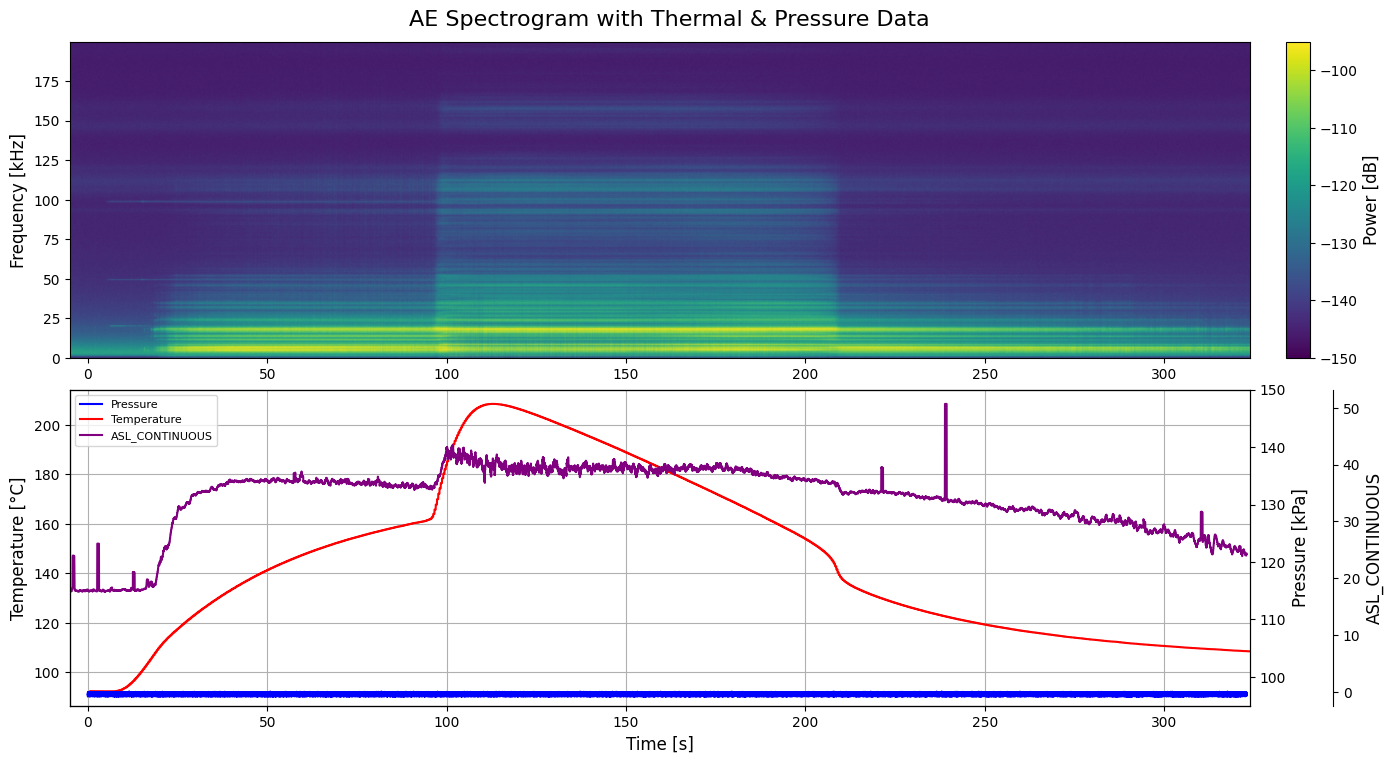

In [ ]:
label_fontsize = 12
tick_fontsize = 10

# Create a figure and GridSpec layout: left column for plots, right column for a narrower colorbar
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[0.98, 0.02],   # relative widths for plots, colorbar
    height_ratios=[1,1],
    hspace=0.10,
    wspace=0.06                  # Small horizontal gap between plots and colorbar
)

ax1 = fig.add_subplot(gs[0, 0])              # Top-left: spectrogram
cax = fig.add_subplot(gs[0, 1])              # Top-right: colorbar axis (aligned with spectrogram)
ax2a = fig.add_subplot(gs[1, 0])              # Bottom-left: trend plot

# ==== Plot spectrogram on ax1 ====  
xmin = masked_spec_times[0] #+ manual_AE_time_adjust
xmax = masked_spec_times[-1] #+ manual_AE_time_adjust
ymin = masked_spec_frequencies[0] / 1e3  # Convert to kHz
ymax = masked_spec_frequencies[-1] / 1e3  # Convert to kHz

spec_img = ax1.imshow(
    masked_Sxx_log,
    extent=[xmin, xmax, ymin, ymax],
    interpolation='bilinear',
    cmap='viridis',
    aspect='auto',
    vmin=min_spectrogram_value_ctrl,
    vmax=max_spectrogram_value_ctrl,
    origin='lower'
)
ax1.set_ylabel('Frequency [kHz]', fontsize=label_fontsize)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax1.tick_params(axis='both', which='major', labelsize=tick_fontsize)

# # # Hide the x-tick labels on ax1, since the bottom-most axis will display shared time axis
# ax1.tick_params(axis='x', labelbottom=False)

# Attach colorbar to the narrower cax axis
cbar = fig.colorbar(spec_img, cax=cax, orientation='vertical')
cbar.set_label('Power [dB]', fontsize=label_fontsize)
cbar.ax.tick_params(labelsize=tick_fontsize)

# Plot the temperature data
ax2a.plot(
    dataframes['temperature']['Time (sec)'],
    dataframes['temperature']['Thermo-couple_1'],
    label='Temperature',
    color='red'
)
ax2a.set_xlim(xmin, xmax)
ax2a.set_xlabel('Time [s]', fontsize=label_fontsize)
ax2a.set_ylabel('Temperature [°C]', fontsize=label_fontsize)
ax2a.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax2a.grid()

# Plot the pressure data
ax2b = ax2a.twinx()
ax2b.plot(
    dataframes['pressure']['Time (sec)'],
    dataframes['pressure']['Pressure (kPa)'],
    label='Pressure',
    color='blue'
)
ax2b.set_ylim(95, 150)
ax2b.set_ylabel('Pressure [kPa]', fontsize=label_fontsize)
ax2b.tick_params(axis='both', which='major', labelsize=tick_fontsize)

# Plot the AE hits/time data
ax2c = ax2a.twinx()
ae_param = 'ASL_CONTINUOUS'  # Change this to the desired parameter
ax2c.plot(
    dataframes['mistras_tdd']['TIME'],
    dataframes['mistras_tdd'][ae_param],
    label=ae_param,
    color='purple'
)
ax2c.set_ylabel(ae_param, fontsize=label_fontsize)
ax2c.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax2c.spines['right'].set_position(('outward', 60))  # Offset the third y-axis


temp_lines, temp_labels = ax2a.get_legend_handles_labels()
pressure_lines, pressure_labels = ax2b.get_legend_handles_labels()
ae_lines, ae_labels = ax2c.get_legend_handles_labels()
ax2a.legend(
    (
        pressure_lines + 
        temp_lines + 
        ae_lines
    ),
    (
        pressure_labels + 
        temp_labels + 
        ae_labels
    ),
    loc='upper left',
    fontsize=8
)

fig.subplots_adjust(top=0.94)  # Lower the top of the subplots, leaving room for suptitle
plt.suptitle(
    f"AE Spectrogram with Thermal & Pressure Data",
    fontsize=16
)
plt.show()

## Plot Scalogram

### Time-Mask Signal for Wavelet Analysis

In [17]:
raise Exception("End of script reached. This is a placeholder to stop execution here for debugging purposes.")

Exception: End of script reached. This is a placeholder to stop execution here for debugging purposes.

## Saturation Temperature & Pressure

In [ ]:
def get_saturation_temperature(pressure):
    # Define the saturation curve data as a dictionary
    # Dictionary: pressure in kPa -> T_saturation in °C from NIST website for Water
    sat_data = {
        1: 6.9696,
        2: 17.495,
        3: 24.079,
        4: 28.96,
        5: 32.874,
        6: 36.159,
        7: 39.0,
        8: 41.509,
        9: 43.761,
        10: 45.806,
        15: 53.969,
        20: 60.058,
        20.149: 60.218,	
        25: 64.963,
        29.33: 68.578680,
        30: 69.095,
        35: 72.681,
        40: 75.857,
        45: 78.715,
        50: 81.317,
        55: 83.709,
        60: 85.926,
        65: 87.993,
        70: 89.932,
        75: 91.758,
        80: 93.486,
        85: 95.125,
        90: 96.687,
        95: 98.178,
        100: 99.606
    }

    # Check if pressure is in the data
    if pressure in sat_data:
        return sat_data[pressure]
    else:
        return "Pressure not in dataset"

# Ask user for pressure in kPa
pressure_kPa = float(input("Enter the pressure in kPa: "))

# Get saturation temperature from the table
T_sat = get_saturation_temperature(pressure_kPa)

print(f"For {pressure_kPa:.1f} kPa, the saturation temperature is: {T_sat} °C")

### Extraction from Dataset

In [ ]:
# Extract data for plotting
# Extract data from Temperature file
df_temp = dataframes['Temperature']
time_temp = df_temp['Time (sec)']
T1 = df_temp['Thermo-couple_1']
T2 = df_temp['Thermo-couple_2']
T3 = df_temp['Thermo-couple_3']
T4 = df_temp['Thermo-couple_4']
T_vapour = df_temp['Vapour Temp']
T_liquid = df_temp['Liquid Temp']

# Extract data from Pressure file
df_press = dataframes['Pressure']
time_press = df_press['Time (sec)']
pressure = df_press['Pressure (kPa)']

'''
# Extract data from Combined file
df_comb = dataframes['Combined']
time_comb = df_comb['Time (sec)']
q_comb = df_comb['Heat Flux (W/cm^2)']
slope_comb = df_comb['Slope']
T_surface_comb = df_comb['T_surface (degC)']
'''

### Heat Flux & HTC calculation

In [ ]:
# Given Constants
k = 392  # Thermal conductivity of Cu (W/mK)
tc_location = np.array([0, 2.54, 5.08, 7.62]) * 1e-3  # Thermocouple locations (meters)
surface_location = 13.1825 * 1e-3  # Surface location relative to the lowest (first) thermocouple position (meters)


# Stack temperature readings into an array
temp_profile = np.column_stack((T1, T2, T3, T4))  # Shape (num_samples, 4)

# Number of thermocouples
n = len(tc_location)

# Least Squares Regression to Fit Temperature Profile
# 1) Compute the slope denominator (same as MATLAB)
slope_denominator = n * np.sum(tc_location**2) - (np.sum(tc_location))**2

# 2) Compute numerator for slope:
#    - Multiply temp_profile (N,4) by tc_location (4,) → (N,4)
#    - Sum along axis=1 to get (N,) for each time step
slope_numerator = n * np.sum(temp_profile * tc_location, axis=1) \
                  - np.sum(tc_location) * np.sum(temp_profile, axis=1)

# 3) Element-wise division to get slope for each time step
slope = slope_numerator / slope_denominator

# Compute Heat Flux using Fourier’s Law
q = - k * slope / 1e4  # Heat flux in W/cm^2 (1e4 converts from W/m^2 to W/cm^2)

# Compute the intercept (b) for the linear fit
# b has shape (N,)
b = (np.sum(temp_profile, axis=1) - slope * np.sum(tc_location)) / n

# Estimate surface temperature using the fitted profile
# temperature_surface has shape (N,)
temperature_surface = slope * surface_location + b

# Compute Heat Transfer Coefficient (HTC)
htc = q / (temperature_surface - T_sat)  # h = q / (T_surface - T_sat)

### Temperature Profile

In [ ]:
## Create the plot
plt.figure(figsize=(20, 10))

# =======================
# 🔹 First Plot: Without T_surface
# =======================
# Plot each temperature sensor with progressively lighter shades
plt.plot(time_temp, T1, label='Thermocouple-1', color='black', linewidth=1)       # Darkest black
plt.plot(time_temp, T2, label='Thermocouple-2', color='dimgray', linewidth=1)     # Dark gray
plt.plot(time_temp, T3, label='Thermocouple-3', color='gray', linewidth=1)        # Medium gray
plt.plot(time_temp, T4, label='Thermocouple-4', color='lightgray', linewidth=1)   # Light gray

# Set axis limits
plt.xlim(time_temp.min(), time_temp.max())  # X-axis from min to max time

# Find the overall min and max from T1, T2, T3, and T4
Temp_min_value = np.min([T1.min(), T2.min(), T3.min(), T4.min()])
Temp_max_value = np.max([T1.max(), T2.max(), T3.max(), T4.max()])

plt.ylim(Temp_min_value-30, Temp_max_value+30)  # Y-axis range (adjust as needed)

# Labels and title
plt.xlabel("Time (seconds)", fontsize=24)
plt.ylabel("Temperature (°C)", fontsize=24)
plt.title(f"Temperature Profile at {pressure_kPa} kPa", fontsize=28)

plt.xticks(fontsize=14)  # Increase x-axis tick size
plt.yticks(fontsize=14)  # Increase y-axis tick size

# Add a legend
plt.legend(fontsize=14)  # Adjust the size (increase as needed)

# Show the grid and plot
plt.grid(True, linestyle='--', alpha=0.9)

# Add a figure border
plt.gcf().patch.set_linewidth(2)  # Set border thickness
plt.gcf().patch.set_edgecolor('black')  # Set border color
plt.show()



In [ ]:
## Create the plot
plt.figure(figsize=(20, 10))
# =======================
# 🔹 Second Plot: With calculated T_surface
# =======================

# Plot each temperature sensor with progressively lighter shades
plt.plot(time_temp, T1, label='Thermocouple-1', color='black', linewidth=1)       # Darkest black
plt.plot(time_temp, T2, label='Thermocouple-2', color='dimgray', linewidth=1)     # Dark gray
plt.plot(time_temp, T3, label='Thermocouple-3', color='gray', linewidth=1)        # Medium gray
plt.plot(time_temp, T4, label='Thermocouple-4', color='lightgray', linewidth=1)   # Light gray
plt.plot(time_temp, temperature_surface, label='Surface_Temp_calculated', color='red', linewidth=2, linestyle='--')   # Light gray

# Set axis limits
plt.xlim(time_temp.min(), time_temp.max())  # X-axis from min to max time

# Find the overall min and max from T1, T2, T3, and T4
Temp_min_value = np.min([T1.min(), T2.min(), T3.min(), T4.min()])
Temp_max_value = np.max([T1.max(), T2.max(), T3.max(), T4.max()])

plt.ylim(Temp_min_value-30, Temp_max_value+30)  # Y-axis range (adjust as needed)

# Labels and title
plt.xlabel("Time (seconds)", fontsize=24)
plt.ylabel("Temperature (°C)", fontsize=24)
plt.title(f"Temperature Profile at {pressure_kPa} kPa", fontsize=28)

plt.xticks(fontsize=14)  # Increase x-axis tick size
plt.yticks(fontsize=14)  # Increase y-axis tick size

# Add a legend
plt.legend(fontsize=14)  # Adjust the size (increase as needed)

# Show the grid and plot
plt.grid(True, linestyle='--', alpha=0.9)

# Add a figure border
plt.gcf().patch.set_linewidth(2)  # Set border thickness
plt.gcf().patch.set_edgecolor('black')  # Set border color
plt.show()



In [ ]:
plt.figure(figsize=(20, 10))
# =======================
# 🔹 Third Plot: With collected T_surface
# =======================

# Plot each temperature sensor with progressively lighter shades
plt.plot(time_temp, T1, label='Thermocouple-1', color='black', linewidth=1)       # Darkest black
plt.plot(time_temp, T2, label='Thermocouple-2', color='dimgray', linewidth=1)     # Dark gray
plt.plot(time_temp, T3, label='Thermocouple-3', color='gray', linewidth=1)        # Medium gray
plt.plot(time_temp, T4, label='Thermocouple-4', color='lightgray', linewidth=1)   # Light gray
plt.plot(time_temp, temperature_surface, label='Surface_Temp_calculated', color='red', linewidth=2, linestyle='--')

'''
plt.plot(time_comb, T_surface_comb, label='Surface_Temp_recorded', color='blue', linewidth=2, linestyle='-')
'''

# Set axis limits
plt.xlim(time_temp.min(), time_temp.max())  # X-axis from min to max time

# Find the overall min and max from T1, T2, T3, and T4
Temp_min_value = np.min([T1.min(), T2.min(), T3.min(), T4.min()])
Temp_max_value = np.max([T1.max(), T2.max(), T3.max(), T4.max()])

plt.ylim(Temp_min_value-30, Temp_max_value+30)  # Y-axis range (adjust as needed)

# Labels and title
plt.xlabel("Time (seconds)", fontsize=24)
plt.ylabel("Temperature (°C)", fontsize=24)
plt.title(f"Temperature Profile at {pressure_kPa} kPa", fontsize=28)

plt.xticks(fontsize=14)  # Increase x-axis tick size
plt.yticks(fontsize=14)  # Increase y-axis tick size

# Add a legend
plt.legend(fontsize=14)  # Adjust the size (increase as needed)

# Show the grid and plot
plt.grid(True, linestyle='--', alpha=0.5)

# Add a figure border
plt.gcf().patch.set_linewidth(2)  # Set border thickness
plt.gcf().patch.set_edgecolor('black')  # Set border color
plt.show()

### Heat Flux and HTC

In [ ]:
# Create a figure with two subplots
plt.figure(figsize=(20, 6))


# Plot each temperature sensor with progressively lighter shades
plt.plot(time_temp, q, color='red', linewidth=2, linestyle='--', label="Heat Flux_calculated")

'''
plt.plot(time_comb, q_comb, color='blue', linewidth=2, linestyle='-', label="Heat Flux_recorded")
'''

# Set axis limits
plt.xlim(time_temp.min(), 100)
#plt.xlim(time.min(), time.max())  # X-axis from min to max time

# Labels and title
plt.xlabel("Time (s)", fontsize=24)
plt.ylabel("Heat Flux (W/cm²)", fontsize=24)
plt.title("Heat Flux vs Time", fontsize=28)
# Add a legend
plt.legend(fontsize=24)
# Generate tick values at 25-second intervals
tick_positions = np.arange(time_temp.min(), time_temp.max() + 1, 25)
# Apply these tick positions to the x-axis
plt.xticks(fontsize=14)  # Increase x-axis tick size
plt.yticks(fontsize=14)  # Increase y-axis tick size
plt.xticks(tick_positions)
# Show the grid and plot
plt.grid(True, linestyle='--', alpha=0.9)
plt.show()

In [ ]:
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d

# Limit to region where CHF typically occurs (e.g., 50–150 seconds)
window_mask = (time_temp > 50) & (time_temp < 150)
time_window = time_temp[window_mask].reset_index(drop=True)  # pandas Series
q_window = q[window_mask]  # numpy array

# Smooth the signal
q_smooth = uniform_filter1d(q_window, size=5)

# Find local peaks with prominence to avoid noise
peaks, properties = find_peaks(q_smooth, prominence=2)

# Pick the most prominent peak (CHF)
if len(peaks) > 0:
    best_peak_idx = peaks[np.argmax(q_smooth[peaks])]
    chf_time = time_window.iloc[best_peak_idx]       # OK (Pandas)
    chf_value = q_window[best_peak_idx]              # ✅ Fixed (NumPy)
    print(f"✅ Refined CHF: {chf_value:.2f} W/cm² at {chf_time:.2f} s")
else:
    print("❌ No valid CHF peak found in window.")


In [ ]:
'''
from scipy.ndimage import uniform_filter1d

# Step 1: Smooth the signal
q_smooth = uniform_filter1d(q, size=5)

# Step 2: Compute slope
dq_dt = np.gradient(q_smooth, time_temp)

# Step 3: Find the first sharp drop after 50s
dip_threshold = -5.0
start_index = np.searchsorted(time_temp, 50)
dip_index = None

for i in range(start_index, len(dq_dt)):
    if dq_dt[i] < dip_threshold:
        dip_index = i
        break

if dip_index is None:
    print("❌ No significant dip found.")
else:
    # Step 4: Search backward to find where the slope last changed from positive to negative
    chf_index = None
    for i in range(dip_index - 1, start_index, -1):
        if dq_dt[i - 1] > 0 and dq_dt[i] <= 0:
            chf_index = i
            break

    if chf_index is None:
        print("❌ No local max before dip found.")
    else:
        chf_time = time_temp[chf_index]
        chf_value = q[chf_index]  # or q_smooth[chf_index] if you prefer
        print(f"✅ Refined CHF: {chf_value:.2f} W/cm² at {chf_time:.2f} s")
'''

In [ ]:
plt.figure(figsize=(20, 10))

# Plot heat flux vs time
plt.plot(time_temp, q, label='Heat Flux', color='blue', linewidth=2)

# Add vertical dashed line at CHF_time
plt.axvline(x=chf_time, color='red', linestyle='--', linewidth=1.5, label=f'CHF Time = {chf_time:.2f}s')

# Add horizontal dashed line at CHF_value
plt.axhline(y=chf_value, color='red', linestyle='--', linewidth=1.5, label=f'CHF = {chf_value:.2f} W/cm²')

# Add a big green dot at the CHF point
plt.scatter(chf_time, chf_value, color='green', s=250, alpha=0.5, label='CHF Point', zorder=5)

# Axis labels and title
plt.xlabel("Time (s)", fontsize=24)
plt.ylabel("Heat Flux (W/cm²)", fontsize=24)
plt.title("Heat Flux vs Time with CHF Annotation", fontsize=24)

# Set axis limits
plt.xlim(time_temp.min(), 150)

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.9)
plt.legend(fontsize=24, loc='center right')

# Generate tick values at 25-second intervals
tick_positions = np.arange(time_temp.min(), 150, 10)
# Apply these tick positions to the x-axis
# Apply ticks and set font size
plt.xticks(tick_positions, fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.show()

### Heat Transfer Coeffient (HTC)

In [ ]:
# Create a figure with two subplots
plt.figure(figsize=(20, 6))


# Plot each temperature sensor with progressively lighter shades
plt.plot(time_temp, htc, color='blue', linewidth=1.5, label="HTC")


# Set axis limits
plt.xlim(time_temp.min(), 100)
#plt.xlim(time.min(), time.max())  # X-axis from min to max time

# Labels and title
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("HTC (W/cm²K)", fontsize=12)
plt.title("Heat Transfer Coefficient vs Time", fontsize=16)
# Add a legend
plt.legend(fontsize=10)
# Generate tick values at 25-second intervals
tick_positions = np.arange(time_temp.min(), time_temp.max() + 1, 25)
# Apply these tick positions to the x-axis
plt.xticks(tick_positions)
# Show the grid and plot
plt.grid(True, linestyle='--', alpha=0.9)
plt.show()

In [ ]:
fig, ax1 = plt.subplots(figsize=(16, 6))

# 🔵 Plot Heat Flux on the left Y-axis
ax1.set_xlabel('Time (s)', fontsize=14)
ax1.set_ylabel('Heat Flux (W/cm²)', color='red', fontsize=24)
l1, = ax1.plot(time_temp, q, color='red', label='Heat Flux', linewidth=2)
ax1.tick_params(axis='x', labelcolor='black', labelsize=14)
ax1.tick_params(axis='y', labelcolor='red', labelsize=14)

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()

# 🔵 Plot HTC on the right Y-axis
ax2.set_ylabel('HTC (W/cm²·K)', color='blue', fontsize=24)
l2, = ax2.plot(time_temp, htc, color='blue', label='HTC', linewidth=2)
ax2.tick_params(axis='y', labelcolor='blue', labelsize=14)

# Title and Grid
plt.title("Heat Flux and HTC superposition", fontsize=28)
ax1.grid(True, linestyle='--', alpha=0.5)

# Combine legends from both axes
lines = [l1, l2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=24)

plt.xlim(time_temp.min(), time_temp.max())  # X-axis from min to max time
plt.tight_layout()
plt.show()

### Saturation Temperature

In [ ]:
plt.figure(figsize=(10, 6))

# Plot vapor and liquid temperature vs. time
plt.plot(time_temp, T_vapour, color='blue', linewidth=1.5, label='Vapour Temperature')
plt.plot(time_temp, T_liquid, color='green', linewidth=1.5, label='Liquid Temperature')

# Draw a horizontal line at T_sat with a legend label showing the pressure
plt.axhline(
    y=T_sat,
    color='red',
    linestyle='--',  # Dotted/dashed line
    linewidth=1.5,
    label="Saturation Temperature"
)

# Set axis limits
plt.xlim(time_temp.min(), time_temp.max())  # X-axis from min to max time
# Find the overall min and max from Vap_T and Liq_T
Temp_fluid_min_value = np.min([T_vapour.min(), T_liquid.min()])
Temp_fluid_max_value = np.max([T_vapour.max(), T_liquid.max()])

plt.ylim(Temp_fluid_min_value-20, Temp_fluid_max_value+20)  # Y-axis range (adjust as needed)

# Axis labels, legend, and title
plt.xlabel("Time (s)", fontsize=14)
plt.ylabel("Temperature (°C)", fontsize=14)
plt.title(f"Saturation Temperature at {pressure_kPa} kPa", fontsize=16)
plt.legend(fontsize=12)

# Place text on the plot to display the numeric T_sat value
# Adjust x-position/time for best placement; here we use 88% of the max time
x_pos = 0.88 * time_temp.max()
plt.text(x_pos, T_sat, f"{T_sat:.3f} °C", color='red', fontsize=12,
         ha='left', va='bottom')


plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# BubbleID

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# bc = Bubble Count
# bs =  Bubble Size
# vp = Vapour Fraction

# Bubble Count & Size Analysis
filepath_bc = "C:\Users\mh272\Box\NED3_Share\Ishraq Hossain\BubbleID\work\SaveData_B-195/bubble_size_bt-Test1.npy"  # Change to your actual path
data_bc = np.load(filepath_bc,allow_pickle=True)

# Vapour Fraction Analysis
filepath_vf = "/home/ishraq1235/Downloads/SteadyStateTutorial/SaveData_B-195/vapor_Test1.npy"  # Change to your actual path
data_vf = np.load(filepath_vf,allow_pickle=True)

In [ ]:
# Step 1: Compute bubble count per frame
count = [len(frame) for frame in data_bc]

# Step 2: Generate time array assuming 300 fps
vidstart = 0
time = [(i / 300) + vidstart for i in range(len(count))]

# Step 3: Create DataFrame and compute rolling average
df = pd.DataFrame({'count': count})
df['rolling_avg'] = df['count'].rolling(window=300).mean()

# Step 4: Plot
plt.figure(figsize=(6, 2))
fig, ax1 = plt.subplots(figsize=(6, 2))
ax1.plot(time, df['count'], color='lightgray', label='Raw Count')
ax1.plot(time, df['rolling_avg'], color='darkblue', label='Rolling Average')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Bubble Count')
ax1.legend()
plt.tight_layout()
plt.show()

In [ ]:
fps = 300
time = np.arange(len(avg_bs_area)) / fps

plt.figure(figsize=(8, 3))
plt.plot(time, avg_bs_area, color='red', label='Avg Bubble Area (cm²)')
plt.xlabel('Time (s)')
plt.ylabel('Avg Bubble Area (cm²)')
plt.title('Average Bubble Area Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Load the vapor fraction data
vf = data_vf / (448 * 384)  # normalize

# Generate time array assuming 150 fps and optional video start offset
vidstart = 0
time = [(i / 300) + vidstart for i in range(len(vf))]

# Create a DataFrame and calculate rolling average
df = pd.DataFrame({'vf': vf})
df['rolling_avg'] = df['vf'].rolling(window=300).mean()

# Plot
plt.figure(figsize=(6, 2))
fig, ax1 = plt.subplots(figsize=(6, 2))
ax1.plot(time, df['vf'], color='lightgray', label='Raw Data')
ax1.plot(time, df['rolling_avg'], color='darkblue', label='Rolling Average')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Vapor Fraction')
ax1.legend()
plt.tight_layout()
plt.show()